### Libaraies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import yaml
warnings.filterwarnings('ignore')

### Step 1: Load Trained Models + Engineered Splits

In [8]:
config_file = os.path.join("..","config","config.yaml")
with open(config_file,"r") as f:
    config = yaml.safe_load(f)
    
    root_dir = os.path.dirname(os.path.dirname(os.path.abspath(config_file)))
    data = os.path.join(root_dir,config["paths"]["engineered_data"])
    load_model = os.path.join(root_dir,config["paths"]["final_models_dir"])

print("Data path: ",data)
print("Model path: ",load_model)

Data path:  c:\Users\DELL\Desktop\loan-risk-system\data/engineered_data/
Model path:  c:\Users\DELL\Desktop\loan-risk-system\models/Final_Models/


In [9]:
X_test_cls_engineered = pd.read_csv(os.path.join(data,"X_test_cls_engineered.csv"))
X_val_cls_engineered = pd.read_csv(os.path.join(data,"X_val_cls_engineered.csv"))
y_test_cls_engineered = pd.read_csv(os.path.join(data,"y_test_cls_engineered.csv"))
y_val_cls_engineered = pd.read_csv(os.path.join(data,"y_val_cls_engineered.csv"))

print("X_test_cls_engineered shape is: ",X_test_cls_engineered.shape)
print("X_val_cls_engineered shape is: ",X_val_cls_engineered.shape)
print("y_test_cls_engineered shape is: ",y_test_cls_engineered.shape)
print("y_val_cls_engineered shape is: ",y_val_cls_engineered.shape)

print("All Classification Engineered Dataset Fully Loaded...")

X_test_cls_engineered shape is:  (2444, 23)
X_val_cls_engineered shape is:  (2444, 23)
y_test_cls_engineered shape is:  (2444, 1)
y_val_cls_engineered shape is:  (2444, 1)
All Classification Engineered Dataset Fully Loaded...


In [10]:
X_test_reg_engineered = pd.read_csv(os.path.join(data,"X_test_reg_engineered.csv"))
X_val_reg_engineered = pd.read_csv(os.path.join(data,"X_val_reg_engineered.csv"))
y_test_reg_engineered = pd.read_csv(os.path.join(data,"y_test_reg_engineered.csv"))
y_val_reg_engineered = pd.read_csv(os.path.join(data,"y_val_reg_engineered.csv"))

print("X_test_reg_engineered shape is: ",X_test_reg_engineered.shape)
print("X_val_reg_engineered shape is: ",X_val_reg_engineered.shape)
print("y_test_reg_engineered shape is: ",y_test_reg_engineered.shape)
print("y_val_reg_engineered shape is: ",y_val_reg_engineered.shape)

print("All Regression Engineered Dataset Fully Loaded...")

X_test_reg_engineered shape is:  (2210, 16)
X_val_reg_engineered shape is:  (2210, 16)
y_test_reg_engineered shape is:  (2210, 1)
y_val_reg_engineered shape is:  (2210, 1)
All Regression Engineered Dataset Fully Loaded...


In [12]:
cls_lightGBM           = joblib.load(os.path.join(load_model,"cls_LightGBM.joblib"))
cls_LogisticRegression = joblib.load(os.path.join(load_model,"cls_LogisticRegression.joblib"))
cls_RandomForest       = joblib.load(os.path.join(load_model,"cls_RandomForest.joblib"))
cls_XGBoost            = joblib.load(os.path.join(load_model,"cls_XGBoost.joblib"))
reg_LightGBM           = joblib.load(os.path.join(load_model,"reg_LightGBM.joblib"))
reg_LinearRegression   = joblib.load(os.path.join(load_model,"reg_LinearRegression.joblib"))
reg_RandomForest       = joblib.load(os.path.join(load_model,"reg_RandomForest.joblib"))
reg_XGBoost            = joblib.load(os.path.join(load_model,"reg_XGBoost.joblib"))
cluster_GMM            = joblib.load(os.path.join(load_model,"cluster_GMM.joblib"))
cluster_KMeans         = joblib.load(os.path.join(load_model,"cluster_KMeans.joblib"))
print("All Models loaded...")

All Models loaded...


In [17]:
cls_models = {
    "cls_lightGBM":cls_lightGBM,
    "cls_LogisticRegression":cls_LogisticRegression,
    "cls_RandomForest":cls_RandomForest,
    "cls_XGBoost":cls_XGBoost
}

reg_models = {
    "reg_LightGBM":reg_LightGBM,
    "reg_LinearRegression":reg_LinearRegression,
    "reg_RandomForest":reg_RandomForest,
    "reg_XGBoost":reg_XGBoost
}

cluster_models = {
    "cluster_GMM":cluster_GMM,
    "cluster_KMeans":cluster_KMeans
}

### Step 2: Threshold Tuning

In [61]:
from sklearn.metrics import f1_score, recall_score

# Default threshold is 0.5
# Lower threshold = catch more defaults = higher recall
# But precision will drop

thresholds = [0.8,0.7,0.6,0.5, 0.4, 0.3, 0.2]

print("THRESHOLD TUNING — LightGBM (Best Model)")

model = cls_models['cls_lightGBM']
y_prob = model.predict_proba(X_val_cls_engineered)[:, 1]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    
    f1      = f1_score(y_val_cls_engineered, y_pred)
    recall  = recall_score(y_val_cls_engineered, y_pred)
    
    from sklearn.metrics import precision_score
    precision = precision_score(y_val_cls_engineered, y_pred)
    
    print(f"\nThreshold: {threshold}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")

print("\n Threshold tuning complete")

THRESHOLD TUNING — LightGBM (Best Model)

Threshold: 0.8
  F1:        0.8075
  Precision: 0.9838
  Recall:    0.6848

Threshold: 0.7
  F1:        0.8229
  Precision: 0.9695
  Recall:    0.7148

Threshold: 0.6
  F1:        0.8245
  Precision: 0.9233
  Recall:    0.7448

Threshold: 0.5
  F1:        0.8153
  Precision: 0.8769
  Recall:    0.7617

Threshold: 0.4
  F1:        0.7962
  Precision: 0.8008
  Recall:    0.7917

Threshold: 0.3
  F1:        0.7741
  Precision: 0.7332
  Recall:    0.8199

Threshold: 0.2
  F1:        0.7201
  Precision: 0.6236
  Recall:    0.8518

 Threshold tuning complete


In [32]:
BEST_THRESHOLD_CLS = 0.6

def predict_cls(model, X):
    """Predict with best threshold"""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= BEST_THRESHOLD_CLS).astype(int)
    return y_pred, y_prob

### Step 2: Classification Report

In [33]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT — FOR EACH MODEL")

for name, model in cls_models.items():
    y_pred, y_prob = predict_cls(model, X_val_cls_engineered)
    
    print(f"\n--- {name} ---")
    print(classification_report(
        y_val_cls_engineered,
        y_pred,
        target_names=['Non-Default (0)', 'Default (1)']))

CLASSIFICATION REPORT — FOR EACH MODEL

--- cls_lightGBM ---
                 precision    recall  f1-score   support

Non-Default (0)       0.93      0.98      0.96      1911
    Default (1)       0.92      0.74      0.82       533

       accuracy                           0.93      2444
      macro avg       0.93      0.86      0.89      2444
   weighted avg       0.93      0.93      0.93      2444


--- cls_LogisticRegression ---
                 precision    recall  f1-score   support

Non-Default (0)       0.91      0.88      0.90      1911
    Default (1)       0.62      0.70      0.66       533

       accuracy                           0.84      2444
      macro avg       0.77      0.79      0.78      2444
   weighted avg       0.85      0.84      0.84      2444


--- cls_RandomForest ---
                 precision    recall  f1-score   support

Non-Default (0)       0.91      1.00      0.95      1911
    Default (1)       0.98      0.65      0.78       533

       accuracy   

In [34]:
# XGBoost and LightGBM both strong candidates

### Step 3: Confusion Matrix

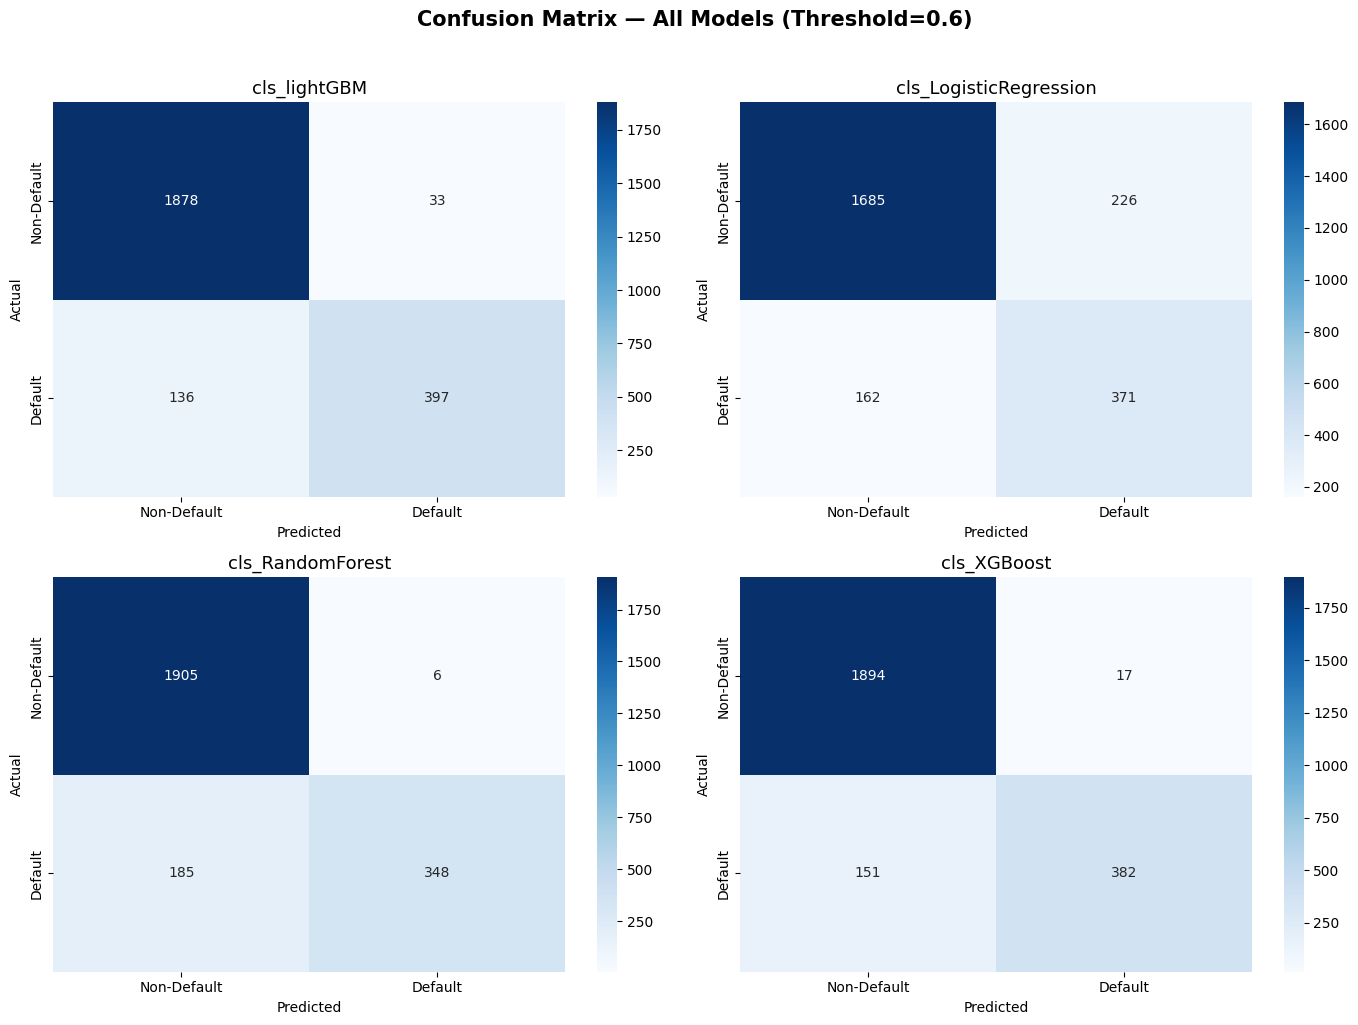

In [35]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(cls_models.items()):
    y_pred, _ = predict_cls(model, X_val_cls_engineered)
    
    cm = confusion_matrix(y_val_cls_engineered, y_pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d',
        ax=axes[idx],
        cmap='Blues',
        xticklabels=['Non-Default', 'Default'],
        yticklabels=['Non-Default', 'Default'])
    
    axes[idx].set_title(f'{name}', fontsize=13)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle(
    f'Confusion Matrix — All Models (Threshold={BEST_THRESHOLD_CLS})',
    fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [37]:
# closer race between LightGBM and XGBoost

###  Step 4: ROC Curve

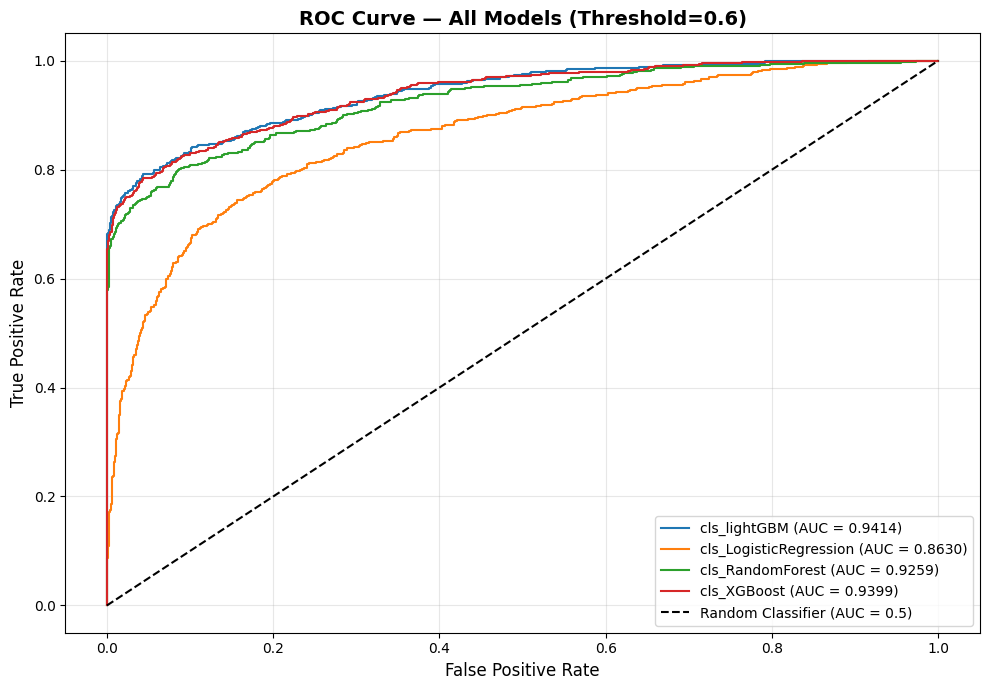

In [38]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))
for name, model in cls_models.items():
    y_pred, y_prob = predict_cls(model, X_val_cls_engineered)
    
    fpr, tpr, _ = roc_curve(y_val_cls_engineered, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — All Models (Threshold={BEST_THRESHOLD_CLS})',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:

# LightGBM is now looking stronger than XGBoost
#   Higher AUC
#   Fewer missed defaulters
#   Phase 13 will make final decision

### Step 5: Residual Plot: Regression
Residual plot shows errors.

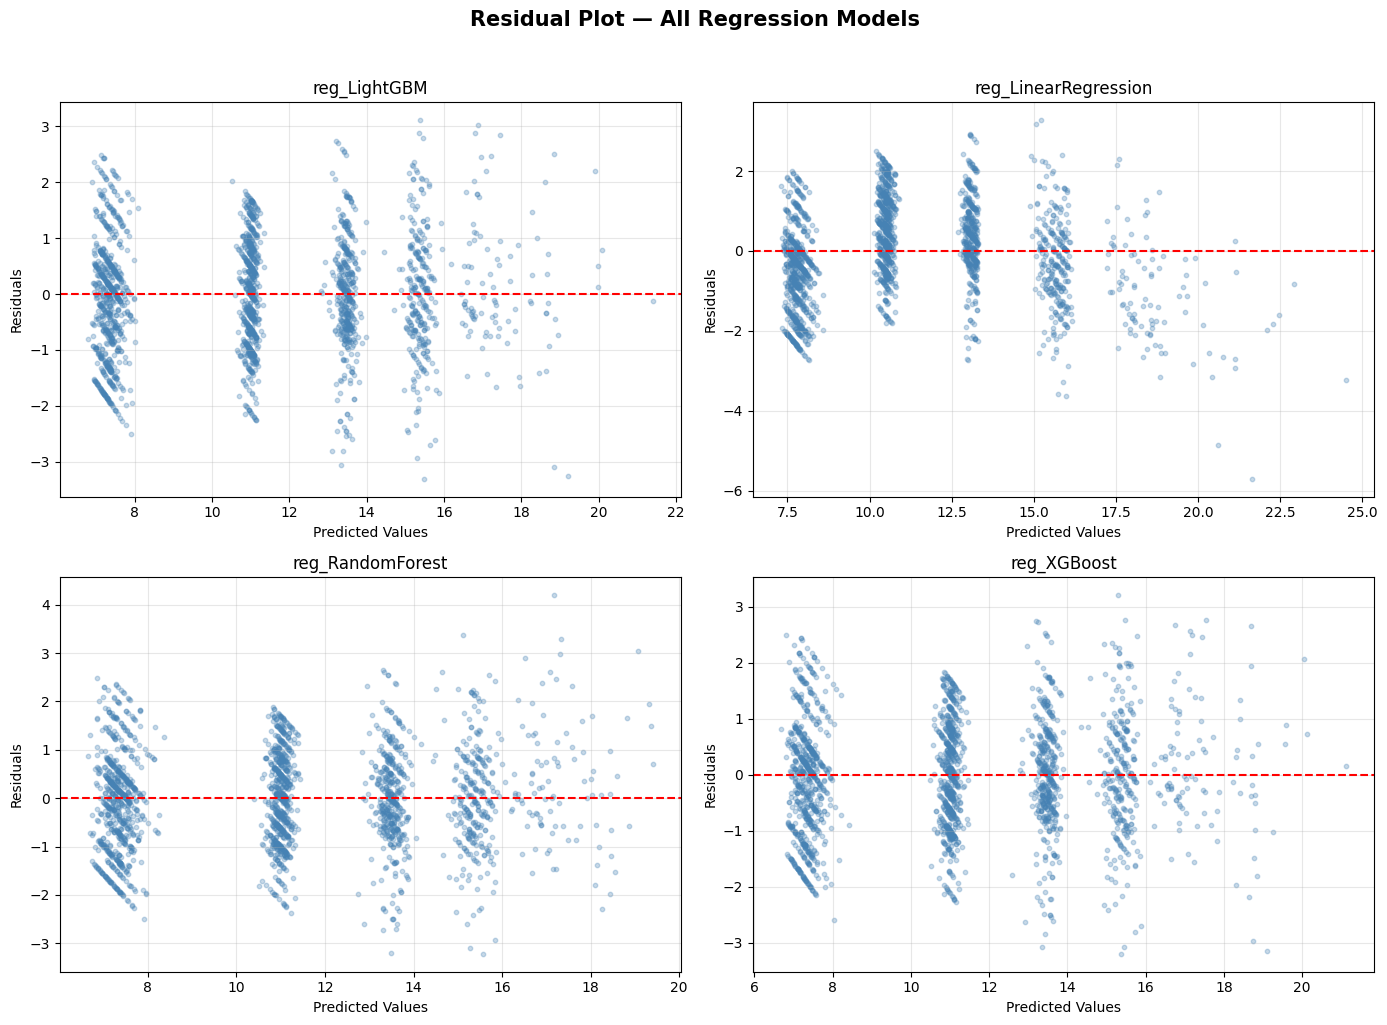

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(reg_models.items()):
    y_pred = model.predict(X_val_reg_engineered)
    residuals = y_val_reg_engineered.values.ravel() - y_pred
    
    axes[idx].scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=10)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_xlabel('Predicted Values')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{name}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Residual Plot — All Regression Models',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# RandomForest best regression model

###  Step 6: Actual vs Predicted Plot

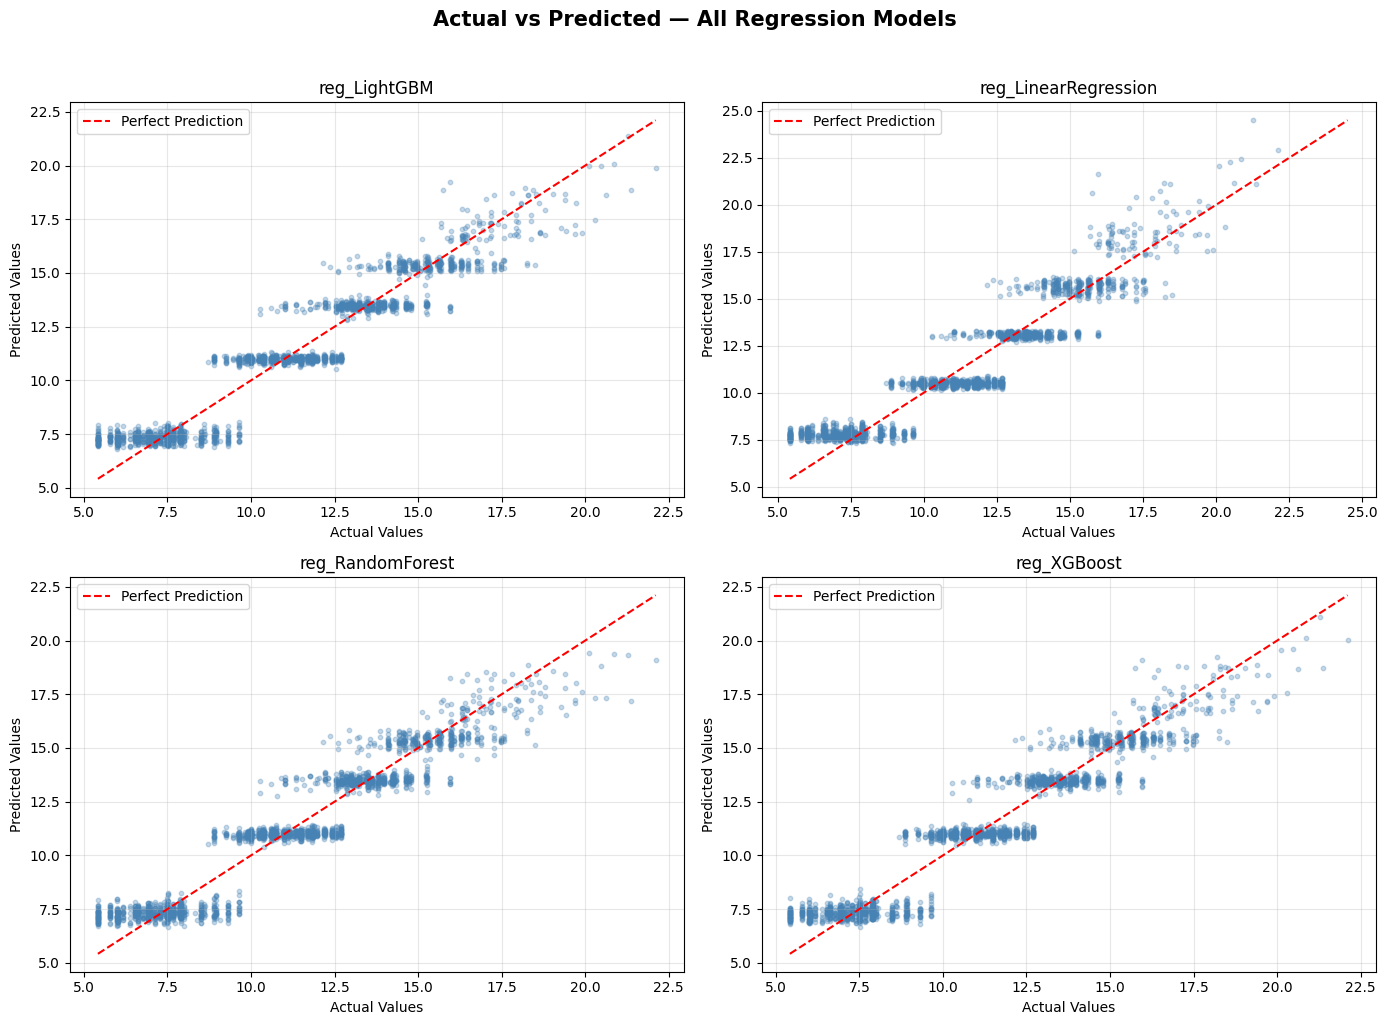

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(reg_models.items()):
    y_pred = model.predict(X_val_reg_engineered)
    y_true = y_val_reg_engineered.values.ravel()
    
    axes[idx].scatter(y_true, y_pred, 
                      alpha=0.3, color='steelblue', s=10)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], 
                   [min_val, max_val], 
                   'r--', linewidth=1.5, label='Perfect Prediction')
    
    axes[idx].set_xlabel('Actual Values')
    axes[idx].set_ylabel('Predicted Values')
    axes[idx].set_title(f'{name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted — All Regression Models',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# Regression ranking confirmed: RandomForest

### Step 7: Cluster Visualization: PCA

PCA Explained Variance: 0.2708


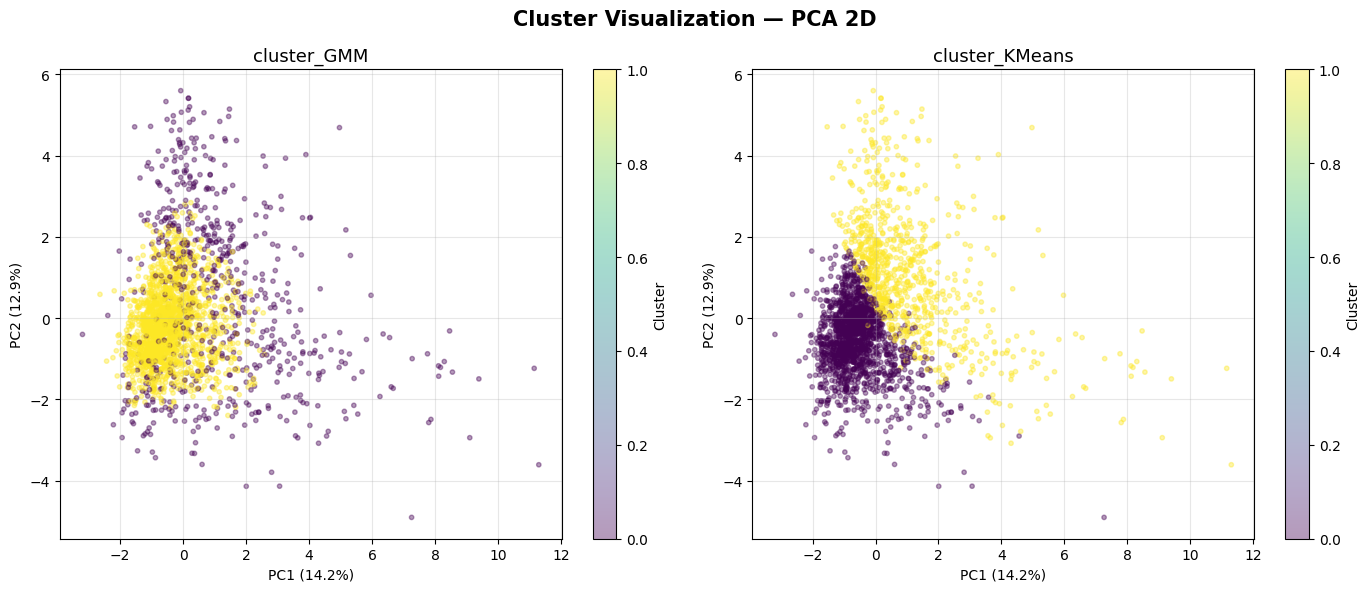

In [46]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_val_cls_engineered)

print(f"PCA Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")

for idx, (name, model) in enumerate(cluster_models.items()):
    # Get labels
    if name == 'cluster_GMM':
        labels = model.predict(X_val_cls_engineered)
    else:
        labels = model.predict(X_val_cls_engineered)

    # Plot
    scatter = axes[idx].scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=labels, cmap='viridis',
        alpha=0.4, s=10)

    axes[idx].set_title(f'{name}', fontsize=13)
    axes[idx].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[idx].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Cluster Visualization — PCA 2D',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 8: Cluster Profiles

In [47]:
# Cluster profiles — what does each cluster look like
# Use original feature names to interpret clusters

# Key features to profile
profile_features = [
    'loan_percent_income',
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'person_age',
    'person_emp_length'
]

for name, model in cluster_models.items():
    print(f"CLUSTER PROFILES — {name}")

    # Get labels
    if name == 'cluster_GMM':
        labels = model.predict(X_val_cls_engineered)
    else:
        labels = model.predict(X_val_cls_engineered)

    # Add labels to dataframe
    X_profile = X_val_cls_engineered.copy()
    X_profile['cluster'] = labels

    # Print cluster sizes
    print(f"\nCluster Sizes:")
    print(X_profile['cluster'].value_counts().sort_index())

    # Print mean of key features per cluster
    print(f"\nCluster Mean Features:")
    profile = X_profile.groupby('cluster')[profile_features].mean().round(4)
    print(profile)

    # Label clusters by risk
    print(f"\nCluster Interpretation:")
    for cluster_id in sorted(X_profile['cluster'].unique()):
        income = profile.loc[cluster_id, 'person_income']
        loan_pct = profile.loc[cluster_id, 'loan_percent_income']
        print(f"  Cluster {cluster_id}: "
              f"income={income:.3f}, "
              f"loan_pct_income={loan_pct:.3f}")

CLUSTER PROFILES — cluster_GMM

Cluster Sizes:
cluster
0     660
1    1784
Name: count, dtype: int64

Cluster Mean Features:
         loan_percent_income  person_income  loan_amnt  loan_int_rate  \
cluster                                                                 
0                     0.3854         0.3566     0.5919         0.4131   
1                    -0.1764        -0.1090    -0.2321        -0.1844   

         person_age  person_emp_length  
cluster                                 
0            0.6184             0.2809  
1           -0.2093            -0.1000  

Cluster Interpretation:
  Cluster 0: income=0.357, loan_pct_income=0.385
  Cluster 1: income=-0.109, loan_pct_income=-0.176
CLUSTER PROFILES — cluster_KMeans

Cluster Sizes:
cluster
0    1617
1     827
Name: count, dtype: int64

Cluster Mean Features:
         loan_percent_income  person_income  loan_amnt  loan_int_rate  \
cluster                                                                 
0                  

In [48]:
# Consistent clustering across both models

### Step 9: Evaluate on Test Set

In [49]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,recall_score, roc_auc_score)

def evaluate_classification(y_true, y_pred, y_prob=None):
    results = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
    }
    if y_prob is not None:
        results['roc_auc'] = roc_auc_score(y_true, y_prob)
    return results

In [50]:
from sklearn.metrics import classification_report

print("TEST SET EVALUATION — CLASSIFICATION")

cls_test_results = {}

for name, model in cls_models.items():
    y_pred, y_prob = predict_cls(model, X_test_cls_engineered)
    
    metrics = evaluate_classification(
        y_test_cls_engineered, y_pred, y_prob)
    
    cls_test_results[name] = metrics
    print(f"\n--- {name} ---")
    print(classification_report(
        y_test_cls_engineered, y_pred,
        target_names=['Non-Default (0)', 'Default (1)']))

print("\n Classification test evaluation complete")

TEST SET EVALUATION — CLASSIFICATION

--- cls_lightGBM ---
                 precision    recall  f1-score   support

Non-Default (0)       0.94      0.98      0.96      1911
    Default (1)       0.93      0.77      0.84       533

       accuracy                           0.94      2444
      macro avg       0.93      0.88      0.90      2444
   weighted avg       0.94      0.94      0.93      2444


--- cls_LogisticRegression ---
                 precision    recall  f1-score   support

Non-Default (0)       0.92      0.86      0.89      1911
    Default (1)       0.61      0.74      0.67       533

       accuracy                           0.84      2444
      macro avg       0.76      0.80      0.78      2444
   weighted avg       0.85      0.84      0.84      2444


--- cls_RandomForest ---
                 precision    recall  f1-score   support

Non-Default (0)       0.92      0.99      0.96      1911
    Default (1)       0.97      0.68      0.80       533

       accuracy     

In [51]:
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)

def evaluate_regression(y_true, y_pred):
    results = {
        'r2':   r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae':  mean_absolute_error(y_true, y_pred)
    }
    return results

In [52]:
print("TEST SET EVALUATION — REGRESSION")

reg_test_results = {}

for name, model in reg_models.items():
    y_pred = model.predict(X_test_reg_engineered)
    
    metrics = evaluate_regression(
        y_test_reg_engineered, y_pred)
    
    reg_test_results[name] = metrics
    print(f"\n{name}: R2={metrics['r2']:.4f}  "
          f"RMSE={metrics['rmse']:.4f}  "
          f"MAE={metrics['mae']:.4f}")

print("\n Regression test evaluation complete")

TEST SET EVALUATION — REGRESSION

reg_LightGBM: R2=0.9066  RMSE=0.9872  MAE=0.7722

reg_LinearRegression: R2=0.8772  RMSE=1.1318  MAE=0.8869

reg_RandomForest: R2=0.9077  RMSE=0.9811  MAE=0.7697

reg_XGBoost: R2=0.9071  RMSE=0.9844  MAE=0.7707

 Regression test evaluation complete


In [53]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,calinski_harabasz_score)

def evaluate_clustering(X, labels):
    # Handle case where only 1 cluster found
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {
            'silhouette':         None,
            'davies_bouldin':     None,
            'calinski_harabasz':  None,
            'n_clusters':         n_clusters
        }
    results = {
        'silhouette':        silhouette_score(X, labels),
        'davies_bouldin':    davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'n_clusters':        n_clusters
    }
    return results

In [55]:
print("TEST SET EVALUATION — CLUSTERING")

cluster_test_results = {}

for name, model in cluster_models.items():
    labels = model.predict(X_val_cls_engineered)
    metrics = evaluate_clustering(X_val_cls_engineered, labels)
    cluster_test_results[name] = metrics
    print(f"\n{name}:")
    print(f"  Silhouette: {metrics['silhouette']:.4f}")
    print(f"  Davies Bouldin: {metrics['davies_bouldin']:.4f}")

print("\n Clustering test evaluation complete")

TEST SET EVALUATION — CLUSTERING

cluster_GMM:
  Silhouette: 0.2287
  Davies Bouldin: 4.2214

cluster_KMeans:
  Silhouette: 0.1584
  Davies Bouldin: 2.8406

 Clustering test evaluation complete


In [ ]:
"""
Final               Model               Rankings after Test Set:    
Task                Best Model          Key Metric

Classification      LightGBMTest        F1=0.84, AUC=0.9414
Regression          RandomForestTest    R2=0.9077, RMSE=0.9811
Clustering          GMM                 Silhouette=0.2287
"""

### Step 10: Save Evaluation Results

In [57]:
import json

# Save test results only — val results already saved in Phase 10

# Save as JSON
test_results = {
    'classification': {
        'test_results':   cls_test_results,
        'best_threshold': BEST_THRESHOLD_CLS
    },
    'regression': {
        'test_results': reg_test_results
    },
    'clustering': {
        'test_results': cluster_test_results
    }
}

with open('../models/Project_Parameter_Files/test_results.json', 'w') as f:
    json.dump(test_results, f, indent=4)

# Save as CSV
pd.DataFrame(cls_test_results).T.round(4).to_csv(
    '../models/Project_Parameter_Files/cls_test_results.csv')
pd.DataFrame(reg_test_results).T.round(4).to_csv(
    '../models/Project_Parameter_Files/reg_test_results.csv')
pd.DataFrame(cluster_test_results).T.round(4).to_csv(
    '../models/Project_Parameter_Files/cluster_test_results.csv')

print(" Test results saved")
print("\nSaved files:")
print("  - models/Project_Parameter_Files/test_results.json")
print("  - models/Project_Parameter_Files/cls_test_results.csv")
print("  - models/Project_Parameter_Files/reg_test_results.csv")
print("  - models/Project_Parameter_Files/cluster_test_results.csv")

 Test results saved

Saved files:
  - models/Project_Parameter_Files/test_results.json
  - models/Project_Parameter_Files/cls_test_results.csv
  - models/Project_Parameter_Files/reg_test_results.csv
  - models/Project_Parameter_Files/cluster_test_results.csv


### Step 11: Document Report

In [58]:
# see report in docs/model_evaluation_report.md